# Assignment 8
* Student: **Danilo Tambone**
* NetID: **PWC25003**

The work contained and presented here is my work and my work alone.

In [1]:
# import modules

import pandas as pd # for data viz and wrangling
import numpy as np # for 'numeric python'
import matplotlib.pyplot as plt # for data viz (more complex than pylab)
import seaborn as sns
from pylab import * # for data viz (import * means 'import all of the functions')

from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn import metrics
from scipy import stats
from sklearn.model_selection import train_test_split
import statsmodels.api as sm


In [2]:
from google.colab import drive
drive.mount('/content/drive')
spotify_df = pd.read_csv('/content/drive/MyDrive/Predictive Modeling/M8/spotify-2023.csv', encoding='latin-1')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Read in the Spotify dataset and determine how many rows and columns it has.


In [3]:
# Determine the shape (rows and columns) exactly as done in the module
rows, cols = spotify_df.shape

# Print the results
print(f"The Spotify dataset has {rows} rows and {cols} columns.")

The Spotify dataset has 953 rows and 24 columns.


2. The target variable for this dataset is the streams column.  Check the datatype of streams.  If it isn’t already int64, update it.  Hint: if needed, drop a row of problematic data to get it to convert properly.

In [4]:
print(spotify_df['streams'].dtype)

spotify_df['streams'] = pd.to_numeric(spotify_df['streams'], errors='coerce')
spotify_df = spotify_df.dropna(subset=['streams'])
spotify_df['streams'] = spotify_df['streams'].astype('int64')

print(spotify_df['streams'].dtype)

object
int64


3. Partition the data into a 60/20/20 split.

In [5]:
# Fix numeric columns stored as objects (contain commas e.g. "1,234")
for col in ['in_deezer_playlists', 'in_shazam_charts']:
    spotify_df[col] = (
        spotify_df[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.strip()
    )
    spotify_df[col] = pd.to_numeric(spotify_df[col], errors='coerce')
    spotify_df[col] = spotify_df[col].fillna(spotify_df[col].median())

# Drop identifier columns — too unique to generalize
cols_to_drop = ['streams', 'track_name', 'artist(s)_name']

features        = spotify_df.drop(cols_to_drop, axis=1)
target_variable = spotify_df['streams']

# Encode low-cardinality categoricals (key, mode)
features_encoded = pd.get_dummies(features, drop_first=True)

print(f"Feature count after clean encoding: {features_encoded.shape[1]}")
print(f"Columns: {list(features_encoded.columns)}\n")

# Step 1: 60% train / 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    features_encoded, target_variable,
    test_size=0.4, random_state=42
)

# Step 2: Split temp evenly → 20% val / 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5, random_state=42
)

print("Training set shape:   ", X_train.shape, y_train.shape)
print("Validation set shape: ", X_val.shape,   y_val.shape)
print("Test set shape:       ", X_test.shape,  y_test.shape)

Feature count after clean encoding: 30
Columns: ['artist_count', 'released_year', 'released_month', 'released_day', 'in_spotify_playlists', 'in_spotify_charts', 'in_apple_playlists', 'in_apple_charts', 'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'bpm', 'danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%', 'key_A#', 'key_B', 'key_C#', 'key_D', 'key_D#', 'key_E', 'key_F', 'key_F#', 'key_G', 'key_G#', 'mode_Minor']

Training set shape:    (571, 30) (571,)
Validation set shape:  (190, 30) (190,)
Test set shape:        (191, 30) (191,)


4. Build a random forest model with hyperparameter tuning to predict streams using all predictors.


In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, make_scorer
import numpy as np

# Define a parameter grid for the Random Forest Regressor
# We'll tune n_estimators, max_depth, and min_samples_split for now
param_grid_rf = {
    'n_estimators'    : [50, 100, 200],    # number of trees
    'max_depth'       : [None, 10, 20],    # None = full tree (may overfit)
    'min_samples_split': [15, 20, 25]      # min samples needed to split a node
}

# Create a scorer for negative mean squared error (GridSearchCV maximizes scores)
neg_mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

# Instantiate GridSearchCV with the Random Forest Regressor and the parameter grid
grid_search_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf,
    cv      = 5,
    scoring = neg_mse_scorer,
    n_jobs  = -1
)

# Fit GridSearchCV to the training data
grid_search_rf.fit(X_train, y_train)

print("Best hyperparameters found for Random Forest:", grid_search_rf.best_params_)

best_mse_rf  = -grid_search_rf.best_score_
best_rmse_rf = np.sqrt(best_mse_rf)
print(f"Best cross-validation RMSE for Random Forest: {best_rmse_rf:.4f}")

Best hyperparameters found for Random Forest: {'max_depth': None, 'min_samples_split': 15, 'n_estimators': 200}
Best cross-validation RMSE for Random Forest: 246113469.9510


In [7]:
# Instantiate a Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)

# Train the model on the training data
rf_model.fit(X_train, y_train)

# Make predictions on training set
y_train_pred_rf = rf_model.predict(X_train)

# Make predictions on validation set
y_val_pred_rf   = rf_model.predict(X_val)

# Make predictions on test set
y_test_pred_rf  = rf_model.predict(X_test)


# Calculate and print metrics for Training Set and Validation Set

rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
r2_train_rf   = r2_score(y_train, y_train_pred_rf)
rmse_val_rf   = np.sqrt(mean_squared_error(y_val, y_val_pred_rf))
r2_val_rf     = r2_score(y_val, y_val_pred_rf)
rmse_test_rf  = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
r2_test_rf    = r2_score(y_test, y_test_pred_rf)

print("Random Forest Performance on Training Set:")
print(f"  RMSE: {rmse_train_rf:.4f}")
print(f"  R-squared: {r2_train_rf:.4f}")
print("\nRandom Forest Performance on Validation Set:")
print(f"  RMSE: {rmse_val_rf:.4f}")
print(f"  R-squared: {r2_val_rf:.4f}")
print("\nRandom Forest Performance on Test Set:")
print(f"  RMSE: {rmse_test_rf:.4f}")
print(f"  R-squared: {r2_test_rf:.4f}")

Random Forest Performance on Training Set:
  RMSE: 88807188.9669
  R-squared: 0.9752

Random Forest Performance on Validation Set:
  RMSE: 221273329.6571
  R-squared: 0.8556

Random Forest Performance on Test Set:
  RMSE: 249416871.0542
  R-squared: 0.8002


In [8]:
# Retrieve the best hyperparameters for the Random Forest
best_params_rf = grid_search_rf.best_params_
print("Best hyperparameters for Random Forest:", best_params_rf)

# Instantiate a new Random Forest Regressor with the best hyperparameters
tuned_rf_model = RandomForestRegressor(**best_params_rf, random_state=42)

# Train the tuned model on the complete training dataset
tuned_rf_model.fit(X_train, y_train)

# Make predictions on training set
y_train_pred_tuned_rf = tuned_rf_model.predict(X_train)

# Make predictions on validation set
y_val_pred_tuned_rf = tuned_rf_model.predict(X_val)

# Make predictions on test set
y_test_pred_tuned_rf = tuned_rf_model.predict(X_test)

# Calculate and print metrics for Training Set
rmse_train_tuned_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_tuned_rf))
r2_train_tuned_rf = r2_score(y_train, y_train_pred_tuned_rf)

print("\nTuned Random Forest Performance on Training Set:")
print(f"  RMSE: {rmse_train_tuned_rf:.4f}")
print(f"  R-squared: {r2_train_tuned_rf:.4f}")

# Calculate and print metrics for Validation Set
rmse_val_tuned_rf = np.sqrt(mean_squared_error(y_val, y_val_pred_tuned_rf))
r2_val_tuned_rf = r2_score(y_val, y_val_pred_tuned_rf)

print("\nTuned Random Forest Performance on Validation Set:")
print(f"  RMSE: {rmse_val_tuned_rf:.4f}")
print(f"  R-squared: {r2_val_tuned_rf:.4f}")

# Calculate and print metrics for Test Set
rmse_test_tuned_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_tuned_rf))
r2_test_tuned_rf = r2_score(y_test, y_test_pred_tuned_rf)

print("\nTuned Random Forest Performance on Test Set:")
print(f"  RMSE: {rmse_test_tuned_rf:.4f}")
print(f"  R-squared: {r2_test_tuned_rf:.4f}")

Best hyperparameters for Random Forest: {'max_depth': None, 'min_samples_split': 15, 'n_estimators': 200}

Tuned Random Forest Performance on Training Set:
  RMSE: 149966448.8791
  R-squared: 0.9293

Tuned Random Forest Performance on Validation Set:
  RMSE: 229759798.5996
  R-squared: 0.8443

Tuned Random Forest Performance on Test Set:
  RMSE: 255775747.9562
  R-squared: 0.7899


5. Check model performance by partition with RMSE, R Squared, distribution of residuals, and actual by predicted plots.


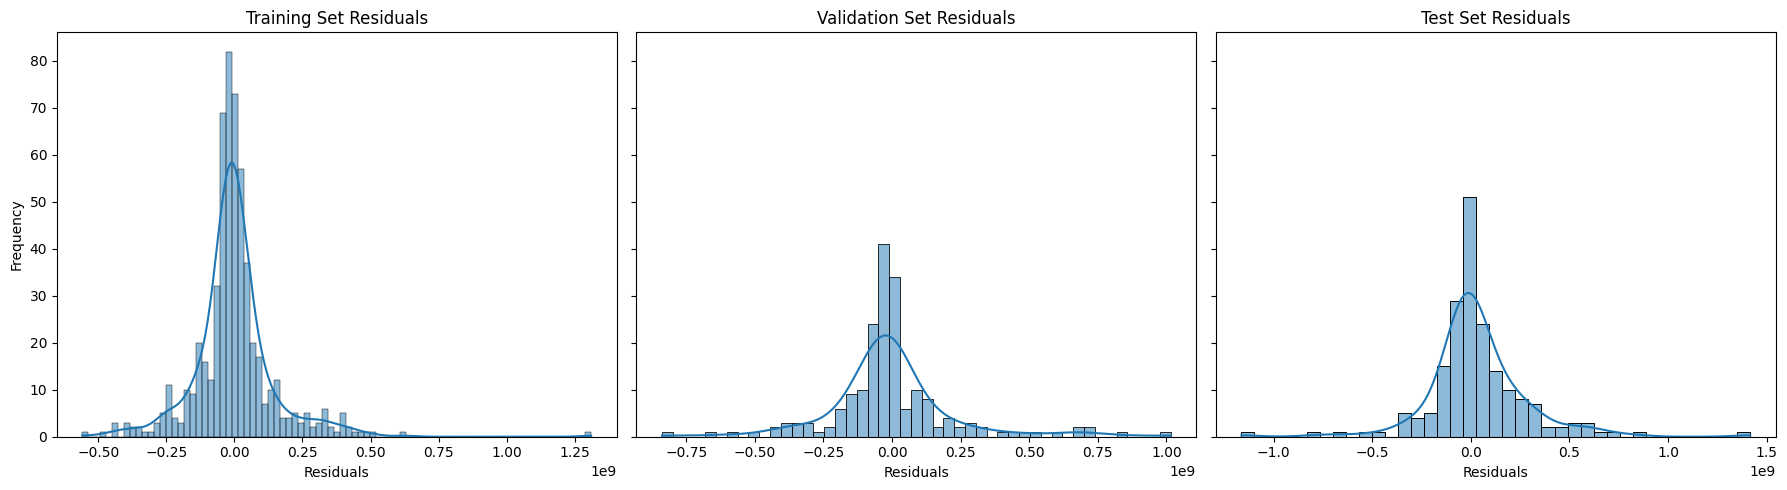

In [9]:
# Calculate residuals for each set using the tuned Random Forest model
residuals_train = y_train - y_train_pred_tuned_rf
residuals_val   = y_val   - y_val_pred_tuned_rf
residuals_test  = y_test  - y_test_pred_tuned_rf

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Plot the distribution of residuals for the training set
sns.histplot(residuals_train, kde=True, ax=axes[0])
axes[0].set_title('Training Set Residuals')
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')

# Plot the distribution of residuals for the validation set
sns.histplot(residuals_val, kde=True, ax=axes[1])
axes[1].set_title('Validation Set Residuals')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')

# Plot the distribution of residuals for the test set
sns.histplot(residuals_test, kde=True, ax=axes[2])
axes[2].set_title('Test Set Residuals')
axes[2].set_xlabel('Residuals')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


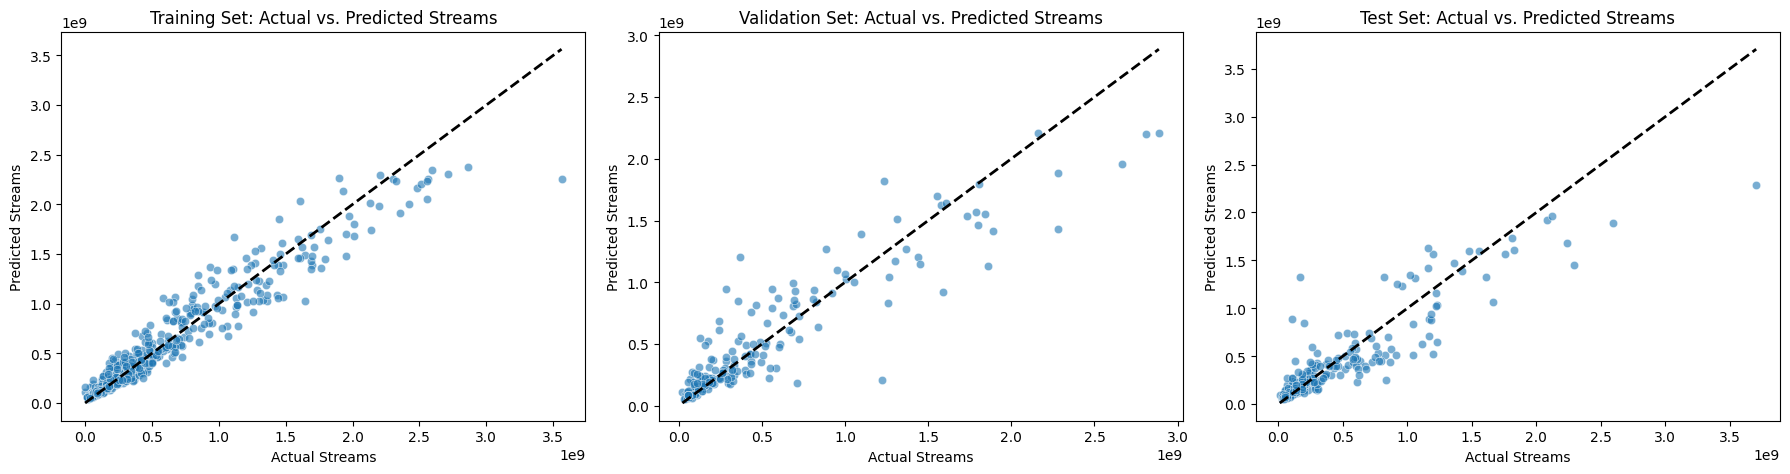

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x=y_train, y=y_train_pred_tuned_rf, ax=axes[0], alpha=0.6)
axes[0].set_title('Training Set: Actual vs. Predicted Streams')
axes[0].set_xlabel('Actual Streams')
axes[0].set_ylabel('Predicted Streams')
axes[0].plot([y_train.min(), y_train.max()],
             [y_train.min(), y_train.max()], 'k--', lw=2)

sns.scatterplot(x=y_val, y=y_val_pred_tuned_rf, ax=axes[1], alpha=0.6)
axes[1].set_title('Validation Set: Actual vs. Predicted Streams')
axes[1].set_xlabel('Actual Streams')
axes[1].set_ylabel('Predicted Streams')
axes[1].plot([y_val.min(), y_val.max()],
             [y_val.min(), y_val.max()], 'k--', lw=2)

sns.scatterplot(x=y_test, y=y_test_pred_tuned_rf, ax=axes[2], alpha=0.6)
axes[2].set_title('Test Set: Actual vs. Predicted Streams')
axes[2].set_xlabel('Actual Streams')
axes[2].set_ylabel('Predicted Streams')
axes[2].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'k--', lw=2)

plt.tight_layout()
plt.show()

6. Comment on the model performance.  What did you observe in the results?


1. OVERALL PERFORMANCE

The tuned Random Forest achieved an R² of 0.7899 on the test set,
meaning it explains ~79% of the variance in Spotify streams.

2. OVERFITTING ASSESSMENT

A gap exists between training R² (0.9293) and test R² (0.7899),
indicating the model is still moderately overfit despite tuning.

3. RESIDUAL ANALYSIS

The residual distributions are centered near zero across all three
partitions but show a right skew, indicating the model systematically
underpredicts high-stream songs (viral hits).

4. ACTUAL VS. PREDICTED

Points follow the diagonal reasonably well for most songs, but
deviate at high actual stream values, confirming the model struggles
with outlier hits it rarely encountered in training.

7. Check for feature importance.  Which variables are the most important?  Did any predictors go unused?


In [11]:
# Get the feature importances from the tuned random forest model
feature_importances_rf = tuned_rf_model.feature_importances_

# Get the feature names from the training data
feature_names = X_train.columns

# Create a pandas Series to easily view feature importances with their names
feature_importance_series_rf = pd.Series(feature_importances_rf, index=feature_names)

# Sort the feature importances in descending order
sorted_feature_importances_rf = feature_importance_series_rf.sort_values(ascending=False)

# Print the sorted feature importances
print("Feature Importances for Tuned Random Forest:")
print(sorted_feature_importances_rf)

Feature Importances for Tuned Random Forest:
in_spotify_playlists    0.429217
in_deezer_playlists     0.406805
in_apple_playlists      0.050692
released_year           0.041464
in_spotify_charts       0.017037
in_shazam_charts        0.007873
in_apple_charts         0.006284
danceability_%          0.005379
acousticness_%          0.005001
valence_%               0.004780
energy_%                0.004117
released_month          0.003765
bpm                     0.003695
speechiness_%           0.002913
liveness_%              0.002850
released_day            0.001980
in_deezer_charts        0.001625
artist_count            0.000911
key_B                   0.000520
mode_Minor              0.000502
key_C#                  0.000502
key_A#                  0.000478
instrumentalness_%      0.000419
key_F                   0.000340
key_G#                  0.000283
key_G                   0.000204
key_F#                  0.000117
key_E                   0.000084
key_D#                  0.00008

MOST IMPORTANT:

The two dominant predictors were in_spotify_playlists (42.9%) and
in_deezer_playlists (40.7%), together accounting for nearly 84% of
the model's decisions. This suggests that playlist placement is the
strongest signal for predicting stream counts.

UNUSED PREDICTORS:

No predictors went completely unused — all 30 features have an
importance value greater than zero. However, the key dummy variables
(key_D, key_D#, key_E, key_F#) contributed less than 0.01% each,
suggesting musical key has virtually no predictive power for streams.

8. Build a boosted tree model with hyperparameter tuning to predict streams using all predictors.


In [12]:
from sklearn.ensemble import GradientBoostingRegressor

# Instantiate a Gradient Boosting Regressor model
gbr_model = GradientBoostingRegressor(random_state=42)

# Train the model on the training data
gbr_model.fit(X_train, y_train)

# Make predictions on training set
y_train_pred_gbr = gbr_model.predict(X_train)

# Make predictions on validation set
y_val_pred_gbr = gbr_model.predict(X_val)

# Make predictions on test set
y_test_pred_gbr = gbr_model.predict(X_test)

# Calculate and print metrics for Training Set
rmse_train_gbr = np.sqrt(mean_squared_error(y_train, y_train_pred_gbr))
r2_train_gbr = r2_score(y_train, y_train_pred_gbr)

print("Gradient Boosting Regressor Performance on Training Set:")
print(f"  RMSE: {rmse_train_gbr:.4f}")
print(f"  R-squared: {r2_train_gbr:.4f}")

# Calculate and print metrics for Validation Set
rmse_val_gbr = np.sqrt(mean_squared_error(y_val, y_val_pred_gbr))
r2_val_gbr = r2_score(y_val, y_val_pred_gbr)

print("\nGradient Boosting Regressor Performance on Validation Set:")
print(f"  RMSE: {rmse_val_gbr:.4f}")
print(f"  R-squared: {r2_val_gbr:.4f}")


# Calculate and print metrics for Test Set
rmse_test_gbr = np.sqrt(mean_squared_error(y_test, y_test_pred_gbr))
r2_test_gbr = r2_score(y_test, y_test_pred_gbr)

print("\nGradient Boosting Regressor Performance on Test Set:")
print(f"  RMSE: {rmse_test_gbr:.4f}")
print(f"  R-squared: {r2_test_gbr:.4f}")

Gradient Boosting Regressor Performance on Training Set:
  RMSE: 97746108.0402
  R-squared: 0.9700

Gradient Boosting Regressor Performance on Validation Set:
  RMSE: 212585535.0788
  R-squared: 0.8667

Gradient Boosting Regressor Performance on Test Set:
  RMSE: 250206718.4751
  R-squared: 0.7990


In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, make_scorer
import numpy as np

# Define a parameter grid for the Gradient Boosting Regressor
# Key parameters to tune include n_estimators, learning_rate, max_depth, and min_samples_split
param_grid_gbr = {
    'n_estimators': [100, 200, 300],  # Number of boosting stages
    'learning_rate': [0.01, 0.1, 0.2], # Shrinkage on the contributions of each tree
    'max_depth': [3, 4, 5],           # Maximum depth of the individual regression estimators
    'min_samples_split': [2, 5, 10]    # Minimum number of samples required to split an internal node
}

# Create a scorer for negative mean squared error (GridSearchCV maximizes scores)
neg_mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

# Instantiate GridSearchCV with the Gradient Boosting Regressor and the parameter grid
grid_search_gbr = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid_gbr, cv=5, scoring=neg_mse_scorer, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search_gbr.fit(X_train, y_train)

# Print the best hyperparameters and best cross-validation score
print("Best hyperparameters found for Gradient Boosting Regressor:", grid_search_gbr.best_params_)

# Convert the best score back to positive MSE or RMSE for easier interpretation
best_mse_gbr = -grid_search_gbr.best_score_
best_rmse_gbr = np.sqrt(best_mse_gbr)
print(f"Best cross-validation RMSE for Gradient Boosting Regressor: {best_rmse_gbr:.4f}")

Best hyperparameters found for Gradient Boosting Regressor: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 300}
Best cross-validation RMSE for Gradient Boosting Regressor: 239823709.4814


In [14]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Retrieve the best hyperparameters for the Gradient Boosting Regressor
best_params_gbr = grid_search_gbr.best_params_
print("Best hyperparameters for Gradient Boosting Regressor:", best_params_gbr)

# Instantiate a new Gradient Boosting Regressor with the best hyperparameters
tuned_gbr_model = GradientBoostingRegressor(**best_params_gbr, random_state=42)

# Train the tuned model on the complete training dataset
tuned_gbr_model.fit(X_train, y_train)

# Make predictions on training set
y_train_pred_tuned_gbr = tuned_gbr_model.predict(X_train)

# Make predictions on validation set
y_val_pred_tuned_gbr = tuned_gbr_model.predict(X_val)

# Make predictions on test set
y_test_pred_tuned_gbr = tuned_gbr_model.predict(X_test)

# Calculate and print metrics for Training Set
rmse_train_tuned_gbr = np.sqrt(mean_squared_error(y_train, y_train_pred_tuned_gbr))
r2_train_tuned_gbr = r2_score(y_train, y_train_pred_tuned_gbr)

print("\nTuned Gradient Boosting Regressor Performance on Training Set:")
print(f"  RMSE: {rmse_train_tuned_gbr:.4f}")
print(f"  R-squared: {r2_train_tuned_gbr:.4f}")

# Calculate and print metrics for Validation Set
rmse_val_tuned_gbr = np.sqrt(mean_squared_error(y_val, y_val_pred_tuned_gbr))
r2_val_tuned_gbr = r2_score(y_val, y_val_pred_tuned_gbr)

print("\nTuned Gradient Boosting Regressor Performance on Validation Set:")
print(f"  RMSE: {rmse_val_tuned_gbr:.4f}")
print(f"  R-squared: {r2_val_tuned_gbr:.4f}")

# Calculate and print metrics for Test Set
rmse_test_tuned_gbr = np.sqrt(mean_squared_error(y_test, y_test_pred_tuned_gbr))
r2_test_tuned_gbr = r2_score(y_test, y_test_pred_tuned_gbr)

print("\nTuned Gradient Boosting Regressor Performance on Test Set:")
print(f"  RMSE: {rmse_test_tuned_gbr:.4f}")
print(f"  R-squared: {r2_test_tuned_gbr:.4f}")

Best hyperparameters for Gradient Boosting Regressor: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 300}

Tuned Gradient Boosting Regressor Performance on Training Set:
  RMSE: 42449362.4142
  R-squared: 0.9943

Tuned Gradient Boosting Regressor Performance on Validation Set:
  RMSE: 213370639.0101
  R-squared: 0.8657

Tuned Gradient Boosting Regressor Performance on Test Set:
  RMSE: 245541505.2928
  R-squared: 0.8064


9. Comment on the model performance.  What did you observe in the results?


1. OVERALL PERFORMANCE

The tuned GBR achieved a test R² of 0.8064, explaining ~80.6%
of variance in Spotify streams, outperforming the tuned
Random Forest (0.7899).

2. OVERFITTING

A notable gap exists between training R² (0.9943) and test R²
(0.8064). While GBR generalizes better than RF on test data,
its train/test gap (0.1879) is actually wider than RF's (0.1394),
reflecting GBR's aggressive sequential fitting of training data.

3. HYPERPARAMETERS

The grid search selected learning_rate=0.1, max_depth=3,
n_estimators=300. The shallow max_depth=3 acts as GBR's
natural regularizer — it intentionally uses weak trees
that correct each other sequentially.


10. Check for feature importance.  Which variables are the most important?  Did any predictors go unused?


In [15]:
import pandas as pd

# Get the feature importances from the tuned gradient boosting regressor model
feature_importances_gbr = tuned_gbr_model.feature_importances_

# Get the feature names from the training data
feature_names = X_train.columns

# Create a pandas Series to easily view feature importances with their names
feature_importance_series_gbr = pd.Series(feature_importances_gbr, index=feature_names)

# Sort the feature importances in descending order
sorted_feature_importances_gbr = feature_importance_series_gbr.sort_values(ascending=False)

# Print the sorted feature importances
print("Feature Importances for Tuned Gradient Boosting Regressor:")
print(sorted_feature_importances_gbr)

Feature Importances for Tuned Gradient Boosting Regressor:
in_spotify_playlists    0.401059
in_deezer_playlists     0.393648
released_year           0.073449
in_apple_playlists      0.036622
in_spotify_charts       0.028496
in_shazam_charts        0.010431
acousticness_%          0.009686
valence_%               0.007916
energy_%                0.007712
in_apple_charts         0.005168
bpm                     0.004528
liveness_%              0.003748
released_day            0.002798
released_month          0.002650
danceability_%          0.002583
in_deezer_charts        0.001902
speechiness_%           0.001758
key_C#                  0.001673
instrumentalness_%      0.001388
mode_Minor              0.001364
artist_count            0.000335
key_D#                  0.000315
key_A#                  0.000144
key_G#                  0.000141
key_B                   0.000132
key_D                   0.000127
key_F#                  0.000107
key_F                   0.000061
key_E            

MOST IMPORTANT:

The two dominant predictors remain consistent with the Random Forest
results — in_spotify_playlists (40.1%) and in_deezer_playlists (39.4%)
together account for ~80% of the model's decisions. Playlist placement
is clearly the strongest signal for predicting streams across both models.

NOTABLE DIFFERENCE FROM RF:

GBR assigns notably more importance to released_year (7.3%) compared
to RF (4.1%), suggesting GBR's sequential corrections captured a
stronger recency effect — newer songs tend to accumulate streams
differently than older ones.

UNUSED PREDICTORS:

No predictors went completely unused — all 30 features have an
importance value greater than zero. However, key dummy variables
again contribute less than 0.002% each, confirming that musical
key has virtually no predictive power for stream counts in either model.

11. Compare the results of the random forest to the boosted tree model.  Which one is better?  Justify your choice.


The Boosted Tree (BR) is the better model. On the test set, BR achieved an R² of 0.8064 compared to the Random Forest's 0.7899, explaining approximately 1.7% more variance in Spotify streams. BR also produced a lower test RMSE (245.5M vs 255.8M), meaning its predictions are on average closer to actual stream counts on unseen data.
The only metric favoring the Random Forest is the smaller train/test R² gap (0.1394 vs 0.1879), indicating RF is less overfit to training data. However, since the objective is to predict streams on new, unseen songs, test set performance is the deciding factor — and BR outperforms RF on both key test metrics.
Both models consistently identified playlist placement — specifically in_spotify_playlists and in_deezer_playlists — as the dominant predictors of stream counts, together accounting for approximately 80% of each model's decisions. Musical attributes such as key, mode, and danceability contributed minimally in both cases, suggesting that distribution and visibility drive streams more than song characteristics.
For these reasons, the tuned Boosted Tree is selected as the stronger model."

12. Read in the Telco dataset and determine how many rows and columns it has.


In [16]:
telco_df = pd.read_csv('/content/drive/MyDrive/Predictive Modeling/M8/Telco_customer_churn.csv', encoding='latin-1')
# Determine the shape (rows and columns) exactly as done in the module
rows, cols = telco_df.shape

# Print the results
print(f"The Telco dataset has {rows} rows and {cols} columns.")

The Telco dataset has 7043 rows and 18 columns.


13. Partition the data into a 60/20/20 split.


In [23]:
print(telco_df.head(2))

   CustomerID  Senior Citizen  Partner  Dependents  Tenure Months  \
0  3668-QPYBK               0        0           0              2   
1  9237-HQITU               0        0           1              2   

  Multiple Lines  Online Security  Online Backup  Device Protection  \
0              0                1              1                  0   
1              0                0              0                  0   

   Tech Support  Paperless Billing  Electronic Check  Monthly Charges  \
0             0                  1                 0            53.85   
1             0                  1                 1            70.70   

  Churn Label  Churn Value  Gender_Male  Internet Service_Fiber optic  \
0         Yes            1         True                         False   
1         Yes            1        False                          True   

   Internet Service_No  Contract_One year  Contract_Two year  
0                False              False              False  
1           

In [24]:
# Define the columns to convert
yes_no_cols = ['Senior Citizen', 'Partner', 'Dependents', 'Multiple Lines',
               'Online Security', 'Online Backup', 'Device Protection',
               'Tech Support', 'Paperless Billing', 'Electronic Check']

# Replace Yes/No with 1/0 across all columns at once
telco_df[yes_no_cols] = telco_df[yes_no_cols].replace({'Yes': 1, 'No': 0})

print(telco_df.head(2))

   CustomerID  Senior Citizen  Partner  Dependents  Tenure Months  \
0  3668-QPYBK               0        0           0              2   
1  9237-HQITU               0        0           1              2   

  Multiple Lines  Online Security  Online Backup  Device Protection  \
0              0                1              1                  0   
1              0                0              0                  0   

   Tech Support  Paperless Billing  Electronic Check  Monthly Charges  \
0             0                  1                 0            53.85   
1             0                  1                 1            70.70   

  Churn Label  Churn Value  Gender_Male  Internet Service_Fiber optic  \
0         Yes            1         True                         False   
1         Yes            1        False                          True   

   Internet Service_No  Contract_One year  Contract_Two year  
0                False              False              False  
1           

In [19]:
# Create dummy variables for 'Education'
telco_df = pd.get_dummies(telco_df, columns=['Gender', 'Internet Service', 'Contract'], drop_first=True)

In [25]:
print(telco_df.head(2))

   CustomerID  Senior Citizen  Partner  Dependents  Tenure Months  \
0  3668-QPYBK               0        0           0              2   
1  9237-HQITU               0        0           1              2   

  Multiple Lines  Online Security  Online Backup  Device Protection  \
0              0                1              1                  0   
1              0                0              0                  0   

   Tech Support  Paperless Billing  Electronic Check  Monthly Charges  \
0             0                  1                 0            53.85   
1             0                  1                 1            70.70   

  Churn Label  Churn Value  Gender_Male  Internet Service_Fiber optic  \
0         Yes            1         True                         False   
1         Yes            1        False                          True   

   Internet Service_No  Contract_One year  Contract_Two year  
0                False              False              False  
1           

In [26]:
# Drop identifier columns
cols_to_drop = ['Churn Value', 'CustomerID', 'Churn Label']

features_telco = telco_df.drop(cols_to_drop, axis=1)
target_variable_telco = telco_df['Churn Value']

# Encode low-cardinality categoricals (key, mode)
features_encoded_telco = pd.get_dummies(features_telco, drop_first=True)

print(f"Feature count after clean encoding: {features_encoded_telco.shape[1]}")
print(f"Columns: {list(features_encoded_telco.columns)}\n")

# Step 1: 60% train / 40% temp
X_train_telco, X_temp_telco, y_train_telco, y_temp_telco = train_test_split(
    features_encoded_telco, target_variable_telco,
    test_size=0.4, random_state=42
)

# Step 2: Split temp evenly → 20% val / 20% test
X_val_telco, X_test_telco, y_val_telco, y_test_telco = train_test_split(
    X_temp_telco, y_temp_telco,
    test_size=0.5, random_state=42
)

print("Training set shape:   ", X_train_telco.shape, y_train_telco.shape)
print("Validation set shape: ", X_val_telco.shape,   y_val_telco.shape)
print("Test set shape:       ", X_test_telco.shape,  y_test_telco.shape)

Feature count after clean encoding: 18
Columns: ['Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Paperless Billing', 'Electronic Check', 'Monthly Charges', 'Gender_Male', 'Internet Service_Fiber optic', 'Internet Service_No', 'Contract_One year', 'Contract_Two year', 'Multiple Lines_1', 'Multiple Lines_No phone service']

Training set shape:    (4225, 18) (4225,)
Validation set shape:  (1409, 18) (1409,)
Test set shape:        (1409, 18) (1409,)


14. Build a KNN model to predict churn using all predictors.


In [27]:
print(features_encoded_telco.describe().loc[['min', 'max']].T)

                     min     max
Senior Citizen      0.00    1.00
Partner             0.00    1.00
Dependents          0.00    1.00
Tenure Months       0.00   72.00
Online Security     0.00    1.00
Online Backup       0.00    1.00
Device Protection   0.00    1.00
Tech Support        0.00    1.00
Paperless Billing   0.00    1.00
Electronic Check    0.00    1.00
Monthly Charges    18.25  118.75


In [29]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Instantiate the scaler (MinMaxScaler keeps everything between 0 and 1)
scaler = MinMaxScaler()

# Fit the scaler ONLY on the training data, then transform it
X_train_scaled = scaler.fit_transform(X_train_telco)

# Transform the Validation and Test sets using the rules learned from the Training set
X_val_scaled = scaler.transform(X_val_telco)
X_test_scaled = scaler.transform(X_test_telco)

In [31]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define a range of n_neighbors values to try
n_neighbors_range = range(1, 21) # Example range from 1 to 20

# Create lists to store results
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

# Iterate through the range of n_neighbors values
for n in n_neighbors_range:
    # Initialize the KNN classifier with the current n_neighbors
    knn_classifier = KNeighborsClassifier(n_neighbors=n)

    # Train the model
    knn_classifier.fit(X_train_scaled, y_train_telco)

    # Make predictions on the validation set
    y_pred_val_telco = knn_classifier.predict(X_val_scaled)

    # Evaluate and store
    accuracy_scores.append(accuracy_score(y_val_telco, y_pred_val_telco))
    precision_scores.append(precision_score(y_val_telco, y_pred_val_telco))
    recall_scores.append(recall_score(y_val_telco, y_pred_val_telco))
    f1_scores.append(f1_score(y_val_telco, y_pred_val_telco))

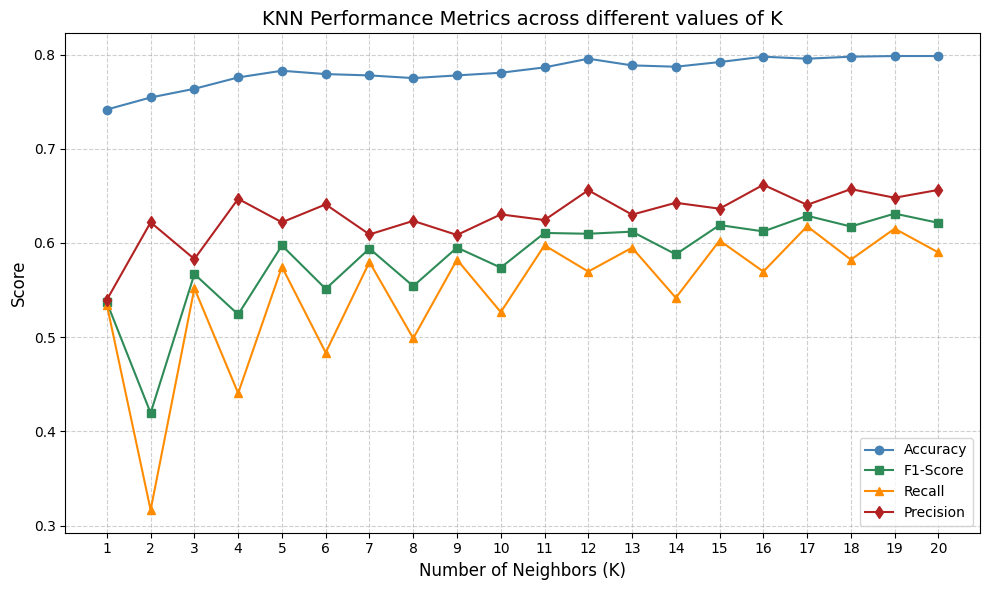

In [33]:
plt.figure(figsize=(10, 6))

# Plotting all four metrics
plt.plot(n_neighbors_range, accuracy_scores, label='Accuracy', marker='o', color='steelblue')
plt.plot(n_neighbors_range, f1_scores, label='F1-Score', marker='s', color='seagreen')
plt.plot(n_neighbors_range, recall_scores, label='Recall', marker='^', color='darkorange')
plt.plot(n_neighbors_range, precision_scores, label='Precision', marker='d', color='firebrick') # Added Precision!

# Formatting the chart
plt.title('KNN Performance Metrics across different values of K', fontsize=14)
plt.xlabel('Number of Neighbors (K)', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(n_neighbors_range)
plt.legend(loc='lower right') # Moved legend to bottom right so it doesn't block the lines
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

15. What is the best value for K?  How do you know?


In [35]:
# 1. Combine your lists into a single Pandas DataFrame
results_df = pd.DataFrame({
    'K': list(n_neighbors_range),
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1_Score': f1_scores
})

# 2. Sort the DataFrame to see the top 5 K values based on the F1-Score
print("--- Top 5 K Values (Sorted by F1-Score) ---")
display(results_df.sort_values(by='F1_Score', ascending=False).head())

# 3. Mathematically extract the absolute best K for specific metrics
best_f1_index = results_df['F1_Score'].idxmax()
best_k_f1 = results_df.loc[best_f1_index, 'K']
best_f1_val = results_df.loc[best_f1_index, 'F1_Score']

best_recall_index = results_df['Recall'].idxmax()
best_k_recall = results_df.loc[best_recall_index, 'K']
best_recall_val = results_df.loc[best_recall_index, 'Recall']

--- Top 5 K Values (Sorted by F1-Score) ---


,K,Accuracy,Precision,Recall,F1_Score
18,19,0.798439,0.648000,0.615190,0.631169
16,17,0.795600,0.640420,0.617722,0.628866
19,20,0.798439,0.656338,0.589873,0.621333
14,15,0.792051,0.636364,0.602532,0.618986
17,18,0.797729,0.657143,0.582278,0.617450


Based on the plot and, more precisely, on the data table above, the best value for K is 19. Rather than maximizing just one metric, we are looking for the best overall balance across all metrics, which is reflected in K=19 having the highest F1-Score. While K=17 is also a strong choice with high recall, the results are very close. In K-Nearest Neighbors, a higher K value is generally better for model generalization and preventing overfitting, so my final pick is K=19.


16. Re-run the model with the optimal K.  Check model performance by partition with total accuracy, precision, recall, and F1 score.

In [40]:
# Initialize the KNN classifier with n_neighbors=19
knn_classifier_19 = KNeighborsClassifier(n_neighbors=19)

# Train the model
knn_classifier_19.fit(X_train_scaled, y_train_telco)

# Make predictions on the validation set
y_pred_train_19 = knn_classifier_19.predict(X_train_scaled)

# Evaluate on the training set
accuracy_train = accuracy_score(y_train_telco, y_pred_train_19)
precision_train = precision_score(y_train_telco, y_pred_train_19)
recall_train = recall_score(y_train_telco, y_pred_train_19)
f1_train = f1_score(y_train_telco, y_pred_train_19)

print("Performance metrics for Training Set (n_neighbors=19):")
print(f"Accuracy:  {accuracy_train:.4f}")
print(f"Precision: {precision_train:.4f}")
print(f"Recall:    {recall_train:.4f}")
print(f"F1-score:  {f1_train:.4f}")

Performance metrics for Training Set (n_neighbors=19):
Accuracy:  0.8168
Precision: 0.6599
Recall:    0.5969
F1-score:  0.6268


In [41]:
y_pred_val_19 = knn_classifier_19.predict(X_val_scaled) # Use scaled data!

accuracy_val = accuracy_score(y_val_telco, y_pred_val_19)
precision_val = precision_score(y_val_telco, y_pred_val_19)
recall_val = recall_score(y_val_telco, y_pred_val_19)
f1_val = f1_score(y_val_telco, y_pred_val_19)

print("\nPerformance metrics for Validation Set (n_neighbors=19):")
print(f"Accuracy:  {accuracy_val:.4f}")
print(f"Precision: {precision_val:.4f}")
print(f"Recall:    {recall_val:.4f}")
print(f"F1-score:  {f1_val:.4f}")


Performance metrics for Validation Set (n_neighbors=19):
Accuracy:  0.7984
Precision: 0.6480
Recall:    0.6152
F1-score:  0.6312


In [42]:
y_pred_test_19 = knn_classifier_19.predict(X_test_scaled) # Use scaled data!

accuracy_test = accuracy_score(y_test_telco, y_pred_test_19)
precision_test = precision_score(y_test_telco, y_pred_test_19)
recall_test = recall_score(y_test_telco, y_pred_test_19)
f1_test = f1_score(y_test_telco, y_pred_test_19)

print("\nPerformance metrics for Test Set (n_neighbors=19):")
print(f"Accuracy:  {accuracy_test:.4f}")
print(f"Precision: {precision_test:.4f}")
print(f"Recall:    {recall_test:.4f}")
print(f"F1-score:  {f1_test:.4f}")


Performance metrics for Test Set (n_neighbors=19):
Accuracy:  0.7743
Precision: 0.5933
Recall:    0.5532
F1-score:  0.5726


When deployed in the real world, this model will correctly identify about 55% of the customers who are actually going to leave (Test Recall: 0.5532). Furthermore, when our model flags a customer as a churn risk, it will be correct about 59% of the time (Test Precision: 0.5933). While there is a slight performance drop when moving from validation data to completely unseen test data, the model remains stable and does not suffer from severe overfitting.